In [2]:
import numpy as np
import pandas as pd
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from scipy.signal import decimate
random = np.random.default_rng(seed=12)    # remove seed for random trials

In [ ]:
def trapezoid_shaper(v: NDArray, tau: float, T: float, k: int, l: int):
    """Shapes input signal pulse into a trapezoid for pulse height measurement.
    Algorithm by Jordanov et al. (1994)

    Args:
        v (np.ndarray): input signal
        tau (float): exponential decay constant
        T (float): sampling period
        k (int): delay parameter
        l (int): delay parameter

    Returns:
        np.ndarray: shaped signal
    """
    n_samples = len(v)  
    M = 1 / (np.exp(T / tau) - 1)   # pole-zero cancellation constant
    max_delay = k + l
    v_padded = np.concatenate(([0] * max_delay, v))     # zero-padding for values before actual signal

    dkl = np.zeros_like(v_padded)
    p = np.zeros_like(v_padded)
    r = np.zeros_like(v_padded)
    s = np.zeros_like(v_padded)

    for n in range(max_delay, n_samples + max_delay):
        dkl[n] = v_padded[n] - v_padded[n - k] - v_padded[n - l] + v_padded[n - k - l]  # Eq. 1: delay-subtract units (see the paper)
        p[n] = p[n - 1] + dkl[n]    # Eq. 2: 1st part of high-pass filter deconvolution (CR + HPD)
        r[n] = p[n] + M*dkl[n]      # Eq. 3: 2nd part of high-pass filter deconvolution
        s[n] = s[n - 1] + r[n]      # Eq. 4: accumulation

    return s[max_delay:]    # remove padding

def rccr2_filter(x: NDArray):
    """
    Apply the three-stage recursive RC-CR2 filter to the input signal x. Parameters taken from
    paper by Krati et al. (2018).

    Args:
        x (numpy.ndarray): Input signal.

    Returns:
        y3 (numpy.ndarray): Output signal after three stages of filtering.
    """
    x = np.asarray(x)
    N = len(x)

    # Initialize output arrays
    y1 = np.zeros(N+1)
    y2 = np.zeros(N+1)
    y3 = np.zeros(N+1)

    for n in range(1, N):
        y1[n] = 0.4 * x[n] + 0. * y1[n-1]                    # RC filter
        y2[n] = 0.91 * y1[n] - 0.91 * y1[n-1] + 0.84 * y2[n-1]  # CR filter
        y3[n] = 0.91 * y2[n] - 0.91 * y2[n-1] + 0.84 * y3[n-1]  # CR filter

    return y3

def add_exp_pulse(s: NDArray, pos: int, a: float, tau: float):
    """Add an exponentially decaying pulse to a base signal at a given position.

    Args:
        s (numpy.ndarray): base signal
        pos (int): starting index of the pulse
        a (float): height of the added pulse
        tau (float): exponential decay constant

    Returns:
        numpy.ndarray: base signal with exponential pulse starting from pos
    """
    samples = len(s)
    x = np.linspace(0, 1, samples)
    x = np.roll(x, pos)
    s1 = a * np.exp(- x / tau)
    s1[:pos] = 0
    return s + s1

def triggers(signal: NDArray, threshold: float):
    """Given a threshold amplitude, find the triggers based on the RC-CR2 filtered signal.

    Args:
        signal (numpy.ndarray): RC-CR2 filtered signal
        threshold (float): threshold amplitude for arming the trigger
    Returns:
        list: trigger indices
    """
    trigger_indices = []
    i = 0
    while i < len(signal):
        # Check what part of the signal is above the threshold (starting from position i)
        over_threshold = np.nonzero((signal[i:] > threshold).astype(np.int64))[0]
        # Check if there are any more samples above the threshold, else break
        if over_threshold.shape[0] > 0:
            threshold_index = over_threshold[0] + i
        else:
            break
        try:
            # Trigger sample is where the signal after the threshold sample crosses zero for the first time
            trigger_index = np.nonzero((signal[threshold_index:] < 0))[0][0]
            # Get position of the trigger in the whole signal (=looping index)
            i = trigger_index + threshold_index
            trigger_indices.append(i)
        except IndexError:
            break

    return trigger_indices

### Jitter analysis

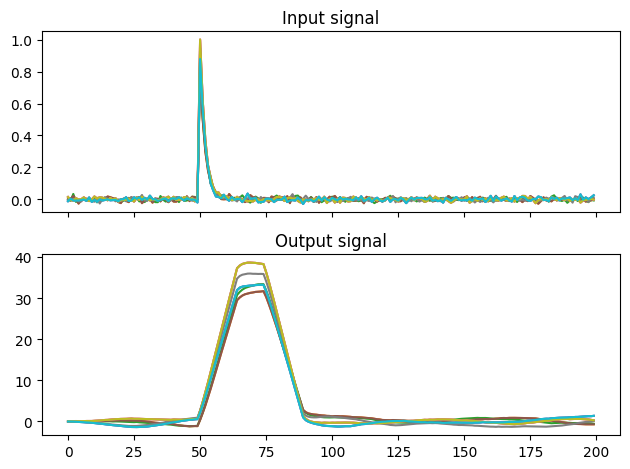

In [44]:
# Jittering MC
repeats = 1000
samples = 2000     # length of signal buffer
T = 0.008           # sample period (tune)
tau = 0.01           # time constant (tune)
k = 15          # filter rise delay (tune)
l = 25             # filter decay delay (tune)
sigma = 0.01        # Gaussian noise standard deviation
a = 1               # amplitude of pulse

#Base signal with Gaussian noise
x = random.normal(0, sigma, size=samples)
signal = add_exp_pulse(x, pos=500, a=1, tau=tau)

# Plotting just as a sanity check
fig, axs = plt.subplots(nrows=2, sharex=True)
maxima = []

for i in range(repeats):
    # Vary the position of the pulse randomly within 10 samples
    random_pos = random.integers(0, 10, 1)[0]
    signal_subsampled = signal[random_pos::10]
    s = trapezoid_shaper(signal_subsampled, tau, T, k, l)
    if i < 10: # plot the first 100 curves
        axs[0].plot(signal_subsampled)
        axs[0].set_title("Input signal")
        axs[1].plot(s)
        axs[1].set_title("Output signal")
    
    # Log the maximum for the histogram plotted in the cell below
    maxima.append(np.nanmax(s))

plt.tight_layout()

Text(0, 0.5, 'N')

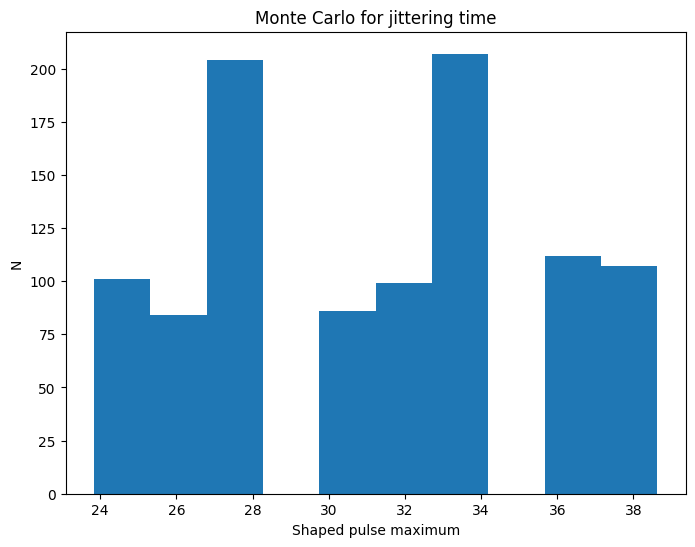

In [45]:
fig, axs = plt.subplots(figsize=(8,6))
plt.title("Monte Carlo for jittering time")
plt.hist(maxima)
plt.xlabel("Shaped pulse maximum")
plt.ylabel("N")

### Simulated data

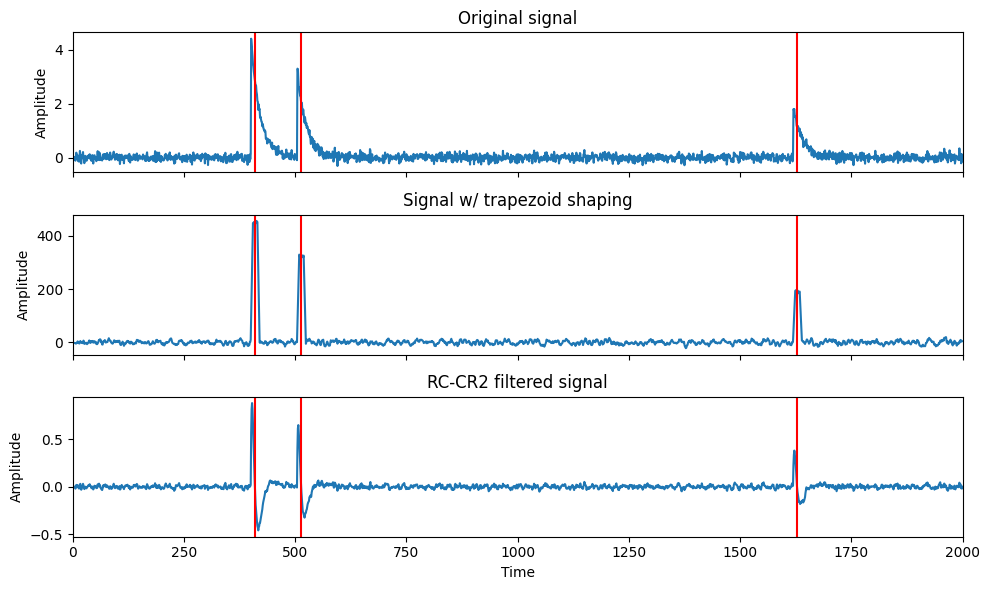

In [50]:
# Random pulse train

samples = 2000     # length of signal buffer
T = 0.0005           # sample period (tune)
tau = 0.01           # time constant (tune)
k = 5              # filter delay 1 (tune)
l = 15             # filter delay 2 (tune)
sigma = 0.1        # Gaussian noise standard deviation
a = 1               # amplitude of pulse

signal = random.normal(0, sigma, size=samples)  # Gaussian noise
rate = 1 / (20 * tau / T)       # rate of pulses
t = 0

# Generate exponentially distributed delays between pulses
pulse_positions = []
while t < samples:
    dt = random.exponential(scale=1/rate)
    t += int(dt)
    if t < samples:
        pulse_positions.append(t)

# Add pulses with amplitude in range [1, 10] at generated pulse positions
for pos in pulse_positions:
    signal = add_exp_pulse(signal, pos=pos, a=random.uniform(1, 10), tau=tau)

trigger_sig = rccr2_filter(signal)  # RC-CR2 filtered signal
trapez_sig = trapezoid_shaper(signal, tau, T, k, l)     # trapezoid shaped pulse

threshold = 0.2
trigs = triggers(trigger_sig, threshold)    # find triggers based on the RC-CR2 output

fig, axs = plt.subplots(nrows=3, sharex=True, figsize=(10, 6))
axs[0].set_title("Original signal")
axs[0].set_ylabel("Amplitude")
axs[0].plot(signal)

axs[1].set_title("Signal w/ trapezoid shaping")
axs[1].set_ylabel("Amplitude")
axs[1].plot(trapez_sig)

axs[2].set_title("RC-CR2 filtered signal")
axs[2].set_ylabel("Amplitude")
axs[2].set_xlabel("Time")
axs[2].plot(trigger_sig)

# Mark triggers with red vertical lines
for ax in axs:
    for trig in trigs:
        ax.axvline(trig, color="red")

axs[2].set_xlim(0, 2000)
plt.tight_layout()

In [5]:
plt.gcf().set_size_inches(10, 6)
plt.show()

<Figure size 1000x600 with 0 Axes>

### Real data

- concatenated measured pulses with random interval sampled from exponential distribution

In [92]:
from scipy.signal import decimate
df = pd.read_csv("data/DataR_D4@N6781_16256_MPPC_Hamamatsu_Plastic_no_source_1_1.csv", header=None, sep=";")

# Example parameters
rate = 1
tau = 0.01
T = 0.005
k = 3
l = 7
sigma = 10

n_pulses = 5     # take the first n rows of the dataframe (one row = one pulse)
signal = np.array([df.iloc[0, 5]])

for i in range(n_pulses):
    pulse = decimate(df.iloc[i, 5:].values.astype(int), q=1)   # antialiasing + downsampling
    pulse = decimate(pulse, q=1)
    # Generate a random time between pulses from exponential distribution
    dt = random.exponential(scale = 1/rate)

    # Linearly interpolate dt amount of samples between two pulses, noise added on top
    signal_between = np.interp(np.arange(dt), [0, dt], [signal[-1], pulse[0]]) + random.normal(0, sigma, int(np.ceil(dt)))
    signal = np.append(signal, signal_between)
    signal = np.append(signal, pulse)


In [95]:
def rccr2_filter(x: NDArray):
    """
    Apply the three-stage recursive RC-CR2 filter to the input signal x. Parameters taken from
    paper by Krati et al. (2018).

    Args:
        x (numpy.ndarray): Input signal.

    Returns:
        y3 (numpy.ndarray): Output signal after three stages of filtering.
    """
    x = np.asarray(x)
    N = len(x)

    # Initialize output arrays
    y1 = np.zeros(N+1)
    y2 = np.zeros(N+1)
    y3 = np.zeros(N+1)

    for n in range(1, N):
        y1[n] = 0.15 * x[n] + 0.84 * y1[n-1]                    # RC filter
        y2[n] = 0.91 * y1[n] - 0.91 * y1[n-1] + 0.84 * y2[n-1]  # CR filter
        y3[n] = 0.91 * y2[n] - 0.91 * y2[n-1] + 0.84 * y3[n-1]  # CR filter

    return y3

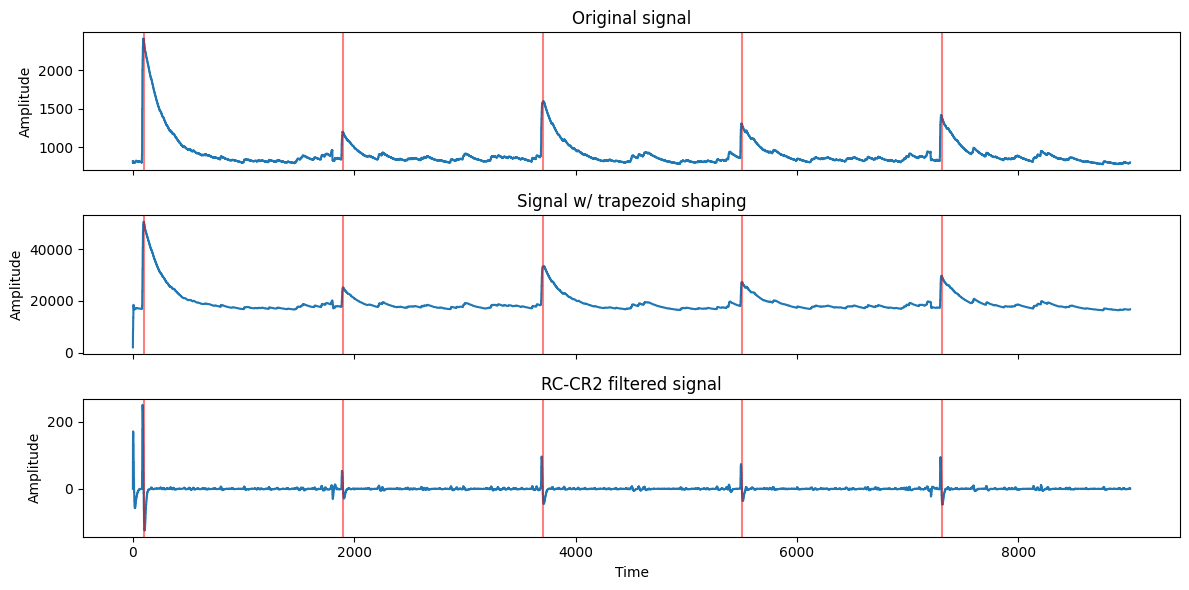

6


In [96]:
trigger_sig = rccr2_filter(signal)
trapez_sig = trapezoid_shaper(signal, tau, T, k, l)

threshold = 20  # tweak this to accept pulses just above the noise floor
trigs = triggers(trigger_sig, threshold)

# Plots
fig, axs = plt.subplots(nrows=3, figsize=(12, 6), sharex=True)
axs[0].set_title("Original signal")
axs[0].set_ylabel("Amplitude")
axs[0].step(np.arange(len(signal)), signal)

axs[1].set_title("Signal w/ trapezoid shaping")
axs[1].set_ylabel("Amplitude")
axs[1].step(np.arange(len(trapez_sig)), trapez_sig)

axs[2].set_title("RC-CR2 filtered signal")
axs[2].set_ylabel("Amplitude")
axs[2].set_xlabel("Time")
axs[2].step(np.arange(len(trigger_sig)), trigger_sig)

# Plot the triggers on each Axes
for ax in axs:
    for trig in trigs[1:]:
        ax.axvline(trig, color="red", alpha=0.5)

# Set limit of x to view a single pulse better
# axs[2].set_xlim(700, 850)
# axs[0].set_ylim(0, 2500)
plt.tight_layout()
plt.show()
print(len(trigs))

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 1.]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1.]),
 <BarContainer object of 19 artists>)

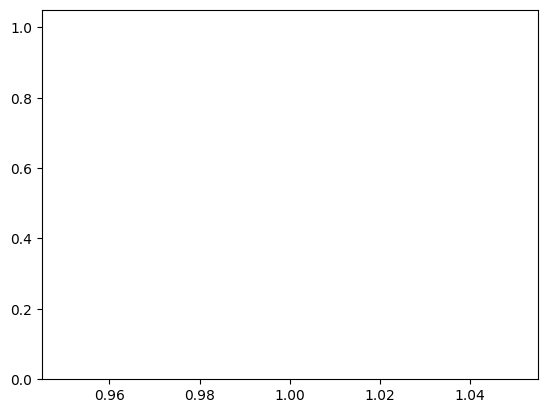

In [97]:
plateau_starts = []
for trig in trigs[1:]:
    try:
        plateau_starts.append((np.argwhere(np.diff(trapez_sig[trig-k-l:trig+k+l], n=2) < -500)[0])[0])
    except IndexError:
        continue

plateau_starts = np.array(plateau_starts)
plt.hist(plateau_starts, bins=np.linspace(min(plateau_starts), max(plateau_starts), 20))